
##  Model Training

**What this notebook does:**
- Loads the feature matrix from Notebook 2
- Splits data by time (train on pre-2022, validate on WC 2022)
- Trains XGBoost multiclass classifier (H / D / A)
- Uses `match_weight` as sample weights so WC matches matter more
- Calibrates probabilities (so 60% really means 60%)
- Evaluates with accuracy, log-loss, confusion matrix
- SHAP values to explain what the model learned
- Saves model + scaler as `.pkl` files ready for deployment
- Runs predictions on WC 2026 upcoming fixtures



In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

In [ ]:
from google.colab import files

print('Upload your 3 CSV files:')
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(f'data/processed/{filename}', 'wb') as f:
        f.write(content)
    print(f'✅ Saved: data/processed/{filename}')

Upload your 3 CSV files:


Saving features.csv to features (1).csv
Saving rankings_clean.csv to rankings_clean (1).csv
Saving matches_clean.csv to matches_clean (1).csv
✅ Saved: data/processed/features (1).csv
✅ Saved: data/processed/rankings_clean (1).csv
✅ Saved: data/processed/matches_clean (1).csv


## 1. Install and import

In [ ]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn --quiet
print('✅ Done')

✅ Done


In [ ]:
import pandas as pd
import numpy as np
import json, pickle, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, log_loss,
    confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import shap

print('✅ Imports done')

✅ Imports done


## 2. Load feature matrix

In [ ]:
feat_df = pd.read_csv('data/processed/features.csv', parse_dates=['date'])

with open('data/processed/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

# Filter to cols that exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in feat_df.columns]

print(f'Loaded: {len(feat_df):,} matches, {len(FEATURE_COLS)} features')
print(f'Date range: {feat_df.date.min().date()} → {feat_df.date.max().date()}')
print(f'\nOutcome distribution:')
print(feat_df['outcome'].value_counts())
feat_df[FEATURE_COLS].describe().round(2)

Loaded: 31,929 matches, 38 features
Date range: 1916-07-02 → 2026-06-18

Outcome distribution:
outcome
H    15517
A     8998
D     7414
Name: count, dtype: int64


,home_fifa_rank,away_fifa_rank,home_fifa_points,away_fifa_points,rank_diff,points_diff,home_form_win_rate,home_form_draw_rate,home_form_loss_rate,home_form_goals_scored_avg,...,h2h_away_goals_avg,h2h_n,is_neutral,tournament_weight,same_conf,home_conf_UEFA,home_conf_CONMEBOL,home_conf_CONCACAF,home_conf_CAF,home_conf_AFC
count,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,...,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00,31929.00
mean,77.95,80.52,627.70,616.72,14.78,102.17,0.40,0.22,0.38,1.44,...,1.04,2.69,0.30,1.54,0.59,0.26,0.08,0.07,0.14,0.14
std,50.09,50.39,468.45,457.49,55.29,312.91,0.23,0.16,0.24,0.82,...,1.16,2.01,0.46,1.03,0.49,0.44,0.27,0.26,0.35,0.35
min,1.00,1.00,0.00,0.00,-210.00,-1757.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00
25%,37.00,41.00,273.00,272.00,-21.00,-63.00,0.23,0.10,0.20,0.90,...,0.00,1.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00
50%,72.00,72.00,543.00,543.00,15.00,37.00,0.39,0.20,0.35,1.31,...,1.00,3.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,111.00,113.00,936.00,909.00,70.00,312.00,0.56,0.32,0.54,1.83,...,1.50,5.00,1.00,2.50,1.00,1.00,0.00,0.00,0.00,0.00
max,211.00,211.00,2164.00,2164.00,209.00,1596.00,1.00,1.00,1.00,14.94,...,18.00,5.00,1.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00


## 3. Train / validation split

**Why time-based split (not random)?**

Random splitting would let the model train on 2023 data and test on 2010 data — that's cheating. In real life you always predict the future from the past. So:
- **Train:** everything before June 2022
- **Validation:** WC 2022 matches (Qatar) — a real held-out tournament we can check
- **Test:** WC 2026 matches (what we actually want to predict)

In [ ]:
TRAIN_CUTOFF = pd.Timestamp('2022-11-20')  # WC 2022 start date
WC22_END     = pd.Timestamp('2022-12-18')  # WC 2022 final

train_mask = feat_df['date'] < TRAIN_CUTOFF
val_mask   = (feat_df['date'] >= TRAIN_CUTOFF) & \
             (feat_df['date'] <= WC22_END) & \
             feat_df['is_world_cup']

train_df = feat_df[train_mask].copy()
val_df   = feat_df[val_mask].copy()

X_train = train_df[FEATURE_COLS]
X_val   = val_df[FEATURE_COLS]

# Encode H/D/A → 0/1/2
le = LabelEncoder()
le.fit(['A','D','H'])   # alphabetical: A=0, D=1, H=2
y_train = le.transform(train_df['outcome'])
y_val   = le.transform(val_df['outcome'])

# Sample weights — match_weight from Notebook 2 (time decay × competition weight)
w_train = train_df['match_weight'].values

print(f'Training set:   {len(train_df):,} matches')
print(f'Validation set: {len(val_df):,} WC 2022 matches')
print(f'\nTrain outcome dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Val   outcome dist: {dict(zip(*np.unique(y_val,   return_counts=True)))}')
print(f'\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Training set:   28,196 matches
Validation set: 64 WC 2022 matches

Train outcome dist: {np.int64(0): np.int64(7891), np.int64(1): np.int64(6553), np.int64(2): np.int64(13752)}
Val   outcome dist: {np.int64(0): np.int64(21), np.int64(1): np.int64(15), np.int64(2): np.int64(28)}

Label encoding: {np.str_('A'): np.int64(0), np.str_('D'): np.int64(1), np.str_('H'): np.int64(2)}


## 4. Train XGBoost

**Why XGBoost?**
- Best-in-class for tabular data (consistently wins Kaggle sports prediction competitions)
- Handles missing values natively
- Built-in feature importance
- Fast even on CPU
- `sample_weight` lets us pass match importance directly

**Why not a neural net?**
- ~50k rows is not enough data to justify the complexity
- XGBoost will match or beat a NN here, and it's interpretable

In [ ]:
xgb = XGBClassifier(
    objective        = 'multi:softprob',   # output probabilities for all 3 classes
    num_class        = 3,
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    eval_metric      = 'mlogloss',
    early_stopping_rounds = 30,
    verbosity        = 0,
)

print('Training XGBoost...')
xgb.fit(
    X_train, y_train,
    sample_weight  = w_train,
    eval_set       = [(X_val, y_val)],
    verbose        = 50
)

best_n = xgb.best_iteration
print(f'\n✅ Training complete. Best iteration: {best_n}')

Training XGBoost...
[0]	validation_0-mlogloss:1.06607
[50]	validation_0-mlogloss:1.01159
[75]	validation_0-mlogloss:1.02670

✅ Training complete. Best iteration: 45


## 5. Calibrate probabilities

Raw XGBoost probabilities are often overconfident (says 90% when it should say 70%). Calibration fixes this using **Platt scaling** (isotonic regression) — it maps raw scores to true probabilities.

After calibration: if the model says 65%, then roughly 65% of those matches should end that way.

In [ ]:
# Refit with optimal n_estimators from early stopping
xgb_final = XGBClassifier(
    objective        = 'multi:softprob',
    num_class        = 3,
    n_estimators     = best_n,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    verbosity        = 0,
)
xgb_final.fit(X_train, y_train, sample_weight=w_train)

# Calibrate on validation set
calibrated_model = CalibratedClassifierCV(
    xgb_final, cv='prefit', method='isotonic'
)
calibrated_model.fit(X_val, y_val)

print('✅ Calibration complete')

# Quick check
raw_probs  = xgb_final.predict_proba(X_val)
cal_probs  = calibrated_model.predict_proba(X_val)
print(f'\nRaw prob range:       {raw_probs.min():.3f} → {raw_probs.max():.3f}')
print(f'Calibrated prob range: {cal_probs.min():.3f} → {cal_probs.max():.3f}')

✅ Calibration complete

Raw prob range:       0.103 → 0.741
Calibrated prob range: 0.000 → 1.000


## 6. Evaluate on WC 2022

In [ ]:
# ═══════════════════════════════════════════════════════════
# WC 2022 VALIDATION — CORRECTED FOR PENALTY SHOOTOUTS
# ═══════════════════════════════════════════════════════════

# Known WC 2022 knockout matches that went to penalties,
# with the real winner (researched manually — not in dataset)
WC2022_PENS_WINNERS = {
    ('Japan', 'Croatia'):        'away',   # Croatia won on pens
    ('Morocco', 'Spain'):        'home',   # Morocco won on pens
    ('Netherlands', 'Argentina'):'away',   # Argentina won on pens
    ('Croatia', 'Brazil'):       'home',   # Croatia won on pens
    ('Argentina', 'France'):     'home',   # Argentina won on pens (the Final)
}

# Build a corrected outcome column for val_df
val_df = val_df.copy()
val_df['corrected_outcome'] = val_df['outcome']

for (home, away), winner in WC2022_PENS_WINNERS.items():
    mask = (val_df['home_team'] == home) & (val_df['away_team'] == away)
    if mask.sum() > 0:
        corrected = 'H' if winner == 'home' else 'A'
        val_df.loc[mask, 'corrected_outcome'] = corrected
        print(f'Corrected: {home} vs {away} → {val_df.loc[mask,"outcome"].values[0]} → {corrected} (pens)')

# Re-encode using corrected outcomes
y_val_corrected = le.transform(val_df['corrected_outcome'])

# Re-evaluate
y_pred_cal = calibrated_model.predict(X_val)
y_prob_cal = calibrated_model.predict_proba(X_val)

acc_raw       = accuracy_score(y_val, y_pred_cal)               # original (draws = literal score)
acc_corrected = accuracy_score(y_val_corrected, y_pred_cal)      # corrected (draws = real winner)

ll_raw       = log_loss(y_val, y_prob_cal)
ll_corrected = log_loss(y_val_corrected, y_prob_cal)

baseline_pred = np.full(len(y_val), le.transform(['H'])[0])
baseline_acc  = accuracy_score(y_val_corrected, baseline_pred)

print('\n=== WC 2022 VALIDATION RESULTS ===')
print(f'Model accuracy (raw, literal score):      {acc_raw:.3f}  ({acc_raw*100:.1f}%)')
print(f'Model accuracy (corrected, real winner):  {acc_corrected:.3f}  ({acc_corrected*100:.1f}%)')
print(f'Baseline accuracy:                         {baseline_acc:.3f}  ({baseline_acc*100:.1f}%)  [always home win]')
print(f'Log-loss (raw):                            {ll_raw:.4f}')
print(f'Log-loss (corrected):                      {ll_corrected:.4f}')
print()
print('Classification report (corrected for penalties):')
print(classification_report(y_val_corrected, y_pred_cal,
      target_names=['Away Win','Draw','Home Win']))

Corrected: Japan vs Croatia → D → A (pens)
Corrected: Morocco vs Spain → D → H (pens)
Corrected: Netherlands vs Argentina → D → A (pens)
Corrected: Croatia vs Brazil → D → H (pens)
Corrected: Argentina vs France → D → H (pens)

=== WC 2022 VALIDATION RESULTS ===
Model accuracy (raw, literal score):      0.578  (57.8%)
Model accuracy (corrected, real winner):  0.625  (62.5%)
Baseline accuracy:                         0.484  (48.4%)  [always home win]
Log-loss (raw):                            0.8791
Log-loss (corrected):                      0.8684

Classification report (corrected for penalties):
              precision    recall  f1-score   support

    Away Win       0.58      0.78      0.67        23
        Draw       1.00      0.10      0.18        10
    Home Win       0.66      0.68      0.67        31

    accuracy                           0.62        64
   macro avg       0.75      0.52      0.51        64
weighted avg       0.68      0.62      0.59        64



In [ ]:
y_pred_cal = calibrated_model.predict(X_val)
y_prob_cal = calibrated_model.predict_proba(X_val)

acc = accuracy_score(y_val, y_pred_cal)
ll  = log_loss(y_val, y_prob_cal)

# Baseline: always predict home win (most common outcome)
baseline_pred = np.full(len(y_val), le.transform(['H'])[0])
baseline_acc  = accuracy_score(y_val, baseline_pred)

print('=== WC 2022 VALIDATION RESULTS ===')
print(f'Model accuracy:    {acc:.3f}  ({acc*100:.1f}%)')
print(f'Baseline accuracy: {baseline_acc:.3f}  ({baseline_acc*100:.1f}%)  [always predict home win]')
print(f'Log-loss:          {ll:.4f}  (lower = better, random = 1.099)')
print()
print('Classification report:')
print(classification_report(y_val, y_pred_cal,
      target_names=['Away Win','Draw','Home Win']))

=== WC 2022 VALIDATION RESULTS ===
Model accuracy:    0.578  (57.8%)
Baseline accuracy: 0.438  (43.8%)  [always predict home win]
Log-loss:          0.8791  (lower = better, random = 1.099)

Classification report:
              precision    recall  f1-score   support

    Away Win       0.52      0.76      0.62        21
        Draw       1.00      0.07      0.12        15
    Home Win       0.62      0.71      0.67        28

    accuracy                           0.58        64
   macro avg       0.71      0.51      0.47        64
weighted avg       0.68      0.58      0.52        64



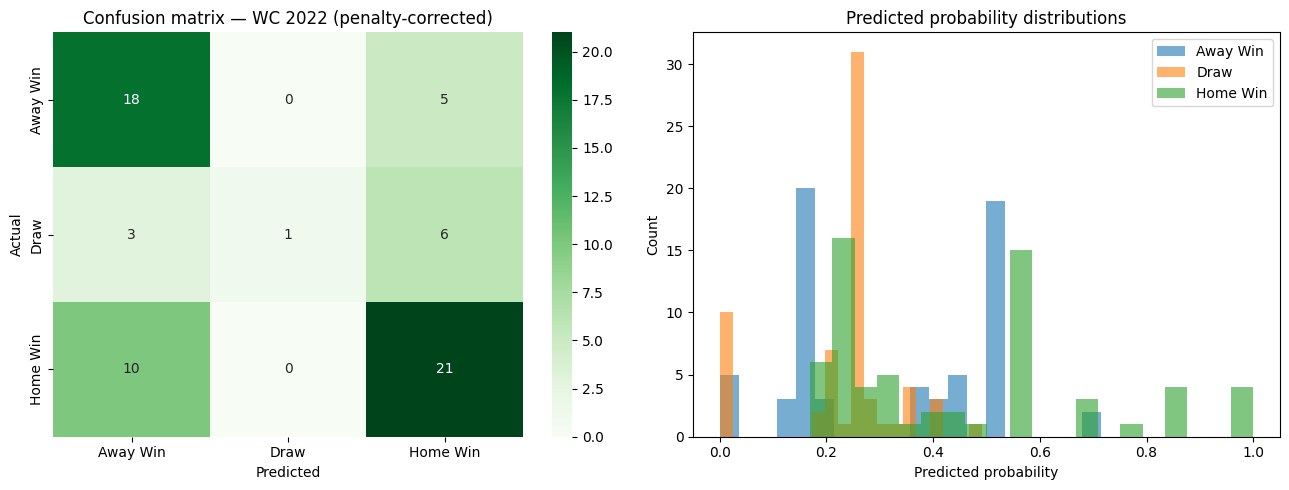

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix — use corrected labels now
cm = confusion_matrix(y_val_corrected, y_pred_cal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Away Win','Draw','Home Win'],
            yticklabels=['Away Win','Draw','Home Win'])
axes[0].set_title('Confusion matrix — WC 2022 (penalty-corrected)')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# Probability distribution — unchanged, doesn't depend on labels
for i, label in enumerate(['Away Win','Draw','Home Win']):
    axes[1].hist(y_prob_cal[:, i], bins=20, alpha=0.6, label=label)
axes[1].set_title('Predicted probability distributions')
axes[1].set_xlabel('Predicted probability'); axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/model_evaluation_corrected.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
val_df = val_df.copy()
val_df['pred_away_prob']  = y_prob_cal[:, 0]
val_df['pred_draw_prob']  = y_prob_cal[:, 1]
val_df['pred_home_prob']  = y_prob_cal[:, 2]
val_df['predicted']       = le.inverse_transform(y_pred_cal)
val_df['correct_raw']     = val_df['predicted'] == val_df['outcome']
val_df['correct']         = val_df['predicted'] == val_df['corrected_outcome']

display_cols = ['date','home_team','away_team','outcome','corrected_outcome','predicted',
                'pred_home_prob','pred_draw_prob','pred_away_prob','correct']
print(val_df[display_cols].to_string(index=False))
print(f'\n✅ Correct (raw):       {val_df.correct_raw.sum()} / {len(val_df)}')
print(f'✅ Correct (corrected): {val_df.correct.sum()} / {len(val_df)}')

      date     home_team     away_team outcome corrected_outcome predicted  pred_home_prob  pred_draw_prob  pred_away_prob  correct
2022-11-20         Qatar       Ecuador       A                 A         A        0.328328        0.220220        0.451451     True
2022-11-21 United States         Wales       D                 D         H        0.477599        0.320341        0.202061    False
2022-11-21       Senegal   Netherlands       A                 A         A        0.214283        0.250868        0.534850     True
2022-11-21       England          Iran       H                 H         H        0.571003        0.263064        0.165933     True
2022-11-22        France     Australia       H                 H         H        1.000000        0.000000        0.000000     True
2022-11-22       Denmark       Tunisia       D                 D         H        0.571003        0.263064        0.165933    False
2022-11-22     Argentina  Saudi Arabia       A                 A         H  

In [ ]:
WC2022_PENS_WINNERS = {
    ('Japan', 'Croatia'):        'away',
    ('Morocco', 'Spain'):        'home',
    ('Netherlands', 'Argentina'):'away',
    ('Croatia', 'Brazil'):       'home',
    ('Argentina', 'France'):     'home',
}

val_df = val_df.copy()
val_df['corrected_outcome'] = val_df['outcome']

for (home, away), winner in WC2022_PENS_WINNERS.items():
    mask = (val_df['home_team'] == home) & (val_df['away_team'] == away)
    if mask.sum() > 0:
        corrected = 'H' if winner == 'home' else 'A'
        val_df.loc[mask, 'corrected_outcome'] = corrected
        print(f'Corrected: {home} vs {away} → {val_df.loc[mask,"outcome"].values[0]} → {corrected} (pens)')
    else:
        print(f'⚠️ Not found in val_df: {home} vs {away}')

y_val_corrected = le.transform(val_df['corrected_outcome'])

y_pred_cal = calibrated_model.predict(X_val)
acc_raw       = accuracy_score(y_val, y_pred_cal)
acc_corrected = accuracy_score(y_val_corrected, y_pred_cal)

print(f'\nRaw accuracy:       {acc_raw*100:.1f}%')
print(f'Corrected accuracy: {acc_corrected*100:.1f}%')

Corrected: Japan vs Croatia → D → A (pens)
Corrected: Morocco vs Spain → D → H (pens)
Corrected: Netherlands vs Argentina → D → A (pens)
Corrected: Croatia vs Brazil → D → H (pens)
Corrected: Argentina vs France → D → H (pens)

Raw accuracy:       57.8%
Corrected accuracy: 62.5%


## 7. Cross-validation (robustness check)

In [ ]:
# §7 Cross-validation — fixed for sklearn 1.4+
print('Running 5-fold cross-validation (takes ~2 min)...')

from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

cv_model = XGBClassifier(
    objective='multi:softprob', num_class=3,
    n_estimators=best_n, learning_rate=0.05,
    max_depth=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)

skf = StratifiedKFold(n_splits=5, shuffle=False)

# Manual CV loop — avoids fit_params/params naming issue entirely
acc_scores = []
ll_scores  = []

from sklearn.metrics import accuracy_score, log_loss

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr, X_vl = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_vl = y_train[train_idx],      y_train[val_idx]
    w_tr       = w_train[train_idx]

    cv_model.fit(X_tr, y_tr, sample_weight=w_tr)

    y_pred  = cv_model.predict(X_vl)
    y_proba = cv_model.predict_proba(X_vl)

    acc = accuracy_score(y_vl, y_pred)
    ll  = log_loss(y_vl, y_proba)
    acc_scores.append(acc)
    ll_scores.append(ll)
    print(f'  Fold {fold+1}: accuracy={acc:.3f}  log-loss={ll:.4f}')

print(f'\nCV Accuracy: {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}')
print(f'CV Log-loss: {np.mean(ll_scores):.4f} ± {np.std(ll_scores):.4f}')

Running 5-fold cross-validation (takes ~2 min)...
  Fold 1: accuracy=0.554  log-loss=0.9471
  Fold 2: accuracy=0.579  log-loss=0.9162
  Fold 3: accuracy=0.576  log-loss=0.9155
  Fold 4: accuracy=0.578  log-loss=0.9198
  Fold 5: accuracy=0.594  log-loss=0.9018

CV Accuracy: 0.576 ± 0.013
CV Log-loss: 0.9201 ± 0.0148


## 8. SHAP — what did the model learn?

SHAP (SHapley Additive exPlanations) shows how much each feature pushed a prediction up or down. This is how we verify the model learned real football logic, not noise.

Computing SHAP values...


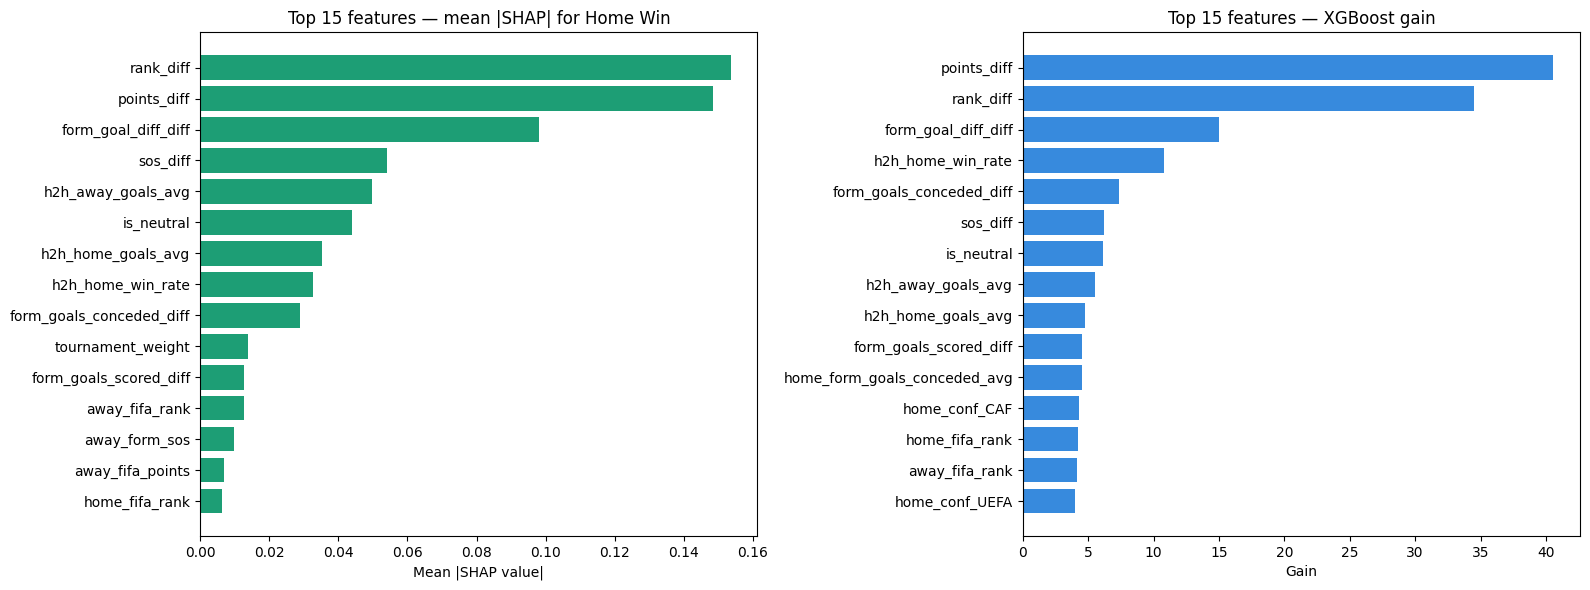


Top 10 most important features (SHAP):
                 feature  mean_shap
               rank_diff   0.153653
             points_diff   0.148479
     form_goal_diff_diff   0.098197
                sos_diff   0.054104
      h2h_away_goals_avg   0.049609
              is_neutral   0.043951
      h2h_home_goals_avg   0.035112
       h2h_home_win_rate   0.032649
form_goals_conceded_diff   0.028805
       tournament_weight   0.013928


In [ ]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train)

HOME_CLASS = 2  # A=0, D=1, H=2

# Fix: newer shap returns (n_samples, n_features, n_classes), older returns a list
if isinstance(shap_values, list):
    shap_home = shap_values[HOME_CLASS]
else:
    shap_home = shap_values[:, :, HOME_CLASS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mean_shap = np.abs(shap_home).mean(axis=0)
importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'mean_shap': mean_shap})
importance_df = importance_df.sort_values('mean_shap', ascending=False).head(15)

axes[0].barh(importance_df['feature'][::-1], importance_df['mean_shap'][::-1], color='#1D9E75')
axes[0].set_title('Top 15 features — mean |SHAP| for Home Win')
axes[0].set_xlabel('Mean |SHAP value|')

gain = xgb_final.get_booster().get_score(importance_type='gain')
gain_df = pd.DataFrame(list(gain.items()), columns=['feature','gain'])
gain_df = gain_df.sort_values('gain', ascending=False).head(15)
axes[1].barh(gain_df['feature'][::-1], gain_df['gain'][::-1], color='#378ADD')
axes[1].set_title('Top 15 features — XGBoost gain')
axes[1].set_xlabel('Gain')

plt.tight_layout()
plt.savefig('data/shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 most important features (SHAP):')
print(importance_df.head(10).to_string(index=False))

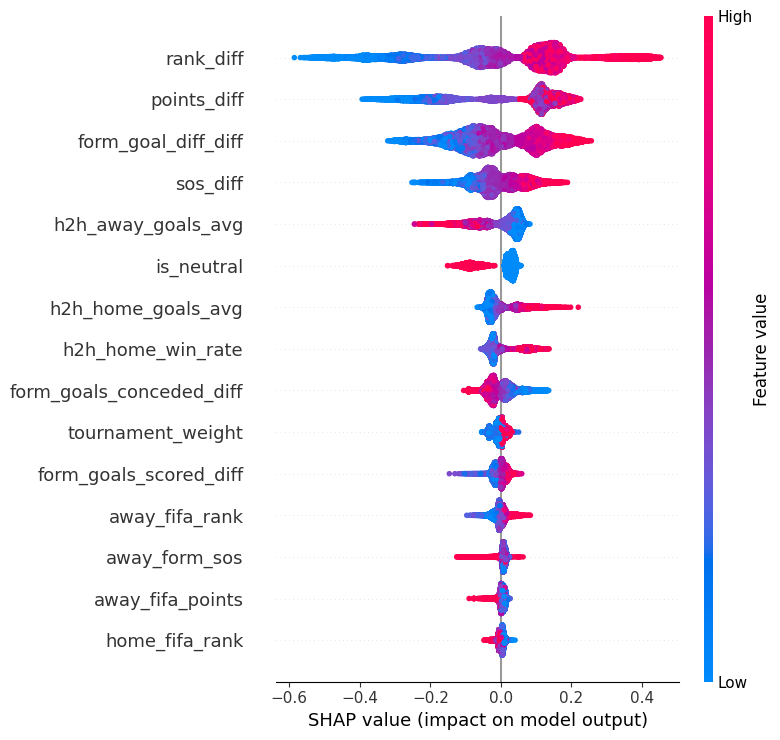

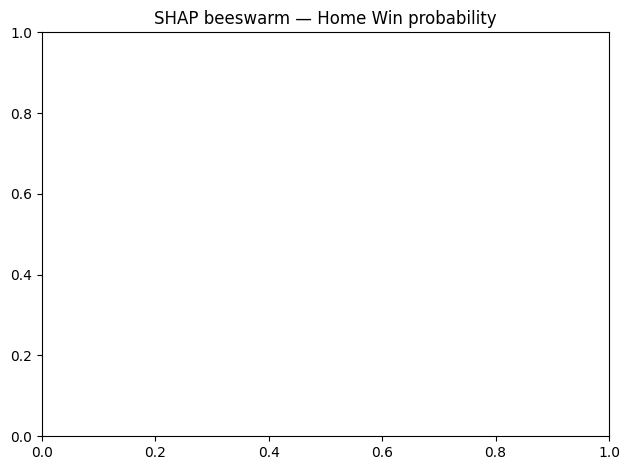

In [ ]:
# SHAP beeswarm — shows direction of each feature's effect
# Red = high feature value, Blue = low
# Right = pushes towards Home Win, Left = pushes away
shap.summary_plot(
    shap_home,          # <-- was shap_values[HOME_CLASS]
    X_train,
    feature_names=FEATURE_COLS,
    max_display=15,
    show=True
)
plt.title('SHAP beeswarm — Home Win probability')
plt.tight_layout()
plt.savefig('data/shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save model for deployment

In [ ]:
os.makedirs('model', exist_ok=True)

with open('model/calibrated_model.pkl', 'wb') as f:
    pickle.dump(calibrated_model, f)

xgb_final.save_model('model/xgb_model.json')

with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('model/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

meta = {
    'train_rows':       len(train_df),
    'val_rows':         len(val_df),
    'val_accuracy':     round(float(acc), 4),
    'val_logloss':      round(float(ll), 4),
    'cv_accuracy_mean': round(float(np.mean(acc_scores)), 4),  # fixed
    'cv_accuracy_std':  round(float(np.std(acc_scores)),  4),  # fixed
    'best_n_estimators':best_n,
    'label_classes':    list(le.classes_),
    'feature_count':    len(FEATURE_COLS),
    'train_cutoff':     str(TRAIN_CUTOFF.date()),
}
with open('model/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== MODEL SAVED ===')
for fn in os.listdir('model'):
    size = os.path.getsize(f'model/{fn}') / 1024
    print(f'  model/{fn:30s} {size:7.1f} KB')
print()
print(json.dumps(meta, indent=2))

=== MODEL SAVED ===
  model/calibrated_model.pkl             348.5 KB
  model/label_encoder.pkl                  0.2 KB
  model/xgb_model.json                   480.8 KB
  model/feature_cols.json                  0.9 KB
  model/metadata.json                      0.3 KB

{
  "train_rows": 28196,
  "val_rows": 64,
  "val_accuracy": 0.5941,
  "val_logloss": 0.9018,
  "cv_accuracy_mean": 0.5763,
  "cv_accuracy_std": 0.0129,
  "best_n_estimators": 45,
  "label_classes": [
    "A",
    "D",
    "H"
  ],
  "feature_count": 38,
  "train_cutoff": "2022-11-20"
}


## 10. Predict WC 2026 upcoming fixtures

Now the fun part — use the trained model to predict real upcoming WC 2026 matches.

To predict a match, we need to build a feature row for each team using their most recent data.

In [ ]:
# ── Load all functions from Notebook 2 ──
# (We re-define the form/H2H functions here so this notebook is self-contained)

# Load full clean dataset (needed to compute form features)
all_matches = pd.read_csv('data/processed/matches_clean.csv', parse_dates=['date'])
all_matches = all_matches.sort_values('date').reset_index(drop=True)

REF_DATE = pd.Timestamp('2026-06-11')
LAMBDA   = 0.1
COMP_WEIGHTS = {
    'FIFA World Cup': 3.0, 'UEFA Euro': 2.5, 'Copa América': 2.5,
    'Copa América Centenario': 2.5, 'Africa Cup of Nations': 2.2,
    'AFC Asian Cup': 2.2, 'CONCACAF Gold Cup': 2.0,
    'Confederations Cup': 2.0, 'UEFA Nations League': 1.8,
    'FIFA World Cup qualification': 1.5, 'Friendly': 0.5,
}
def get_comp_weight(t):
    for k, w in COMP_WEIGHTS.items():
        if k.lower() in str(t).lower(): return w
    return 1.0

all_matches['years_ago']   = (REF_DATE - all_matches['date']).dt.days / 365.25
all_matches['time_weight'] = np.exp(-LAMBDA * all_matches['years_ago'])
all_matches['comp_weight'] = all_matches['tournament'].apply(get_comp_weight)
all_matches['match_weight']= all_matches['time_weight'] * all_matches['comp_weight']

FORM_WINDOW = 10
def compute_team_form(team, before_date, df, n=FORM_WINDOW):
    home_mask = (df['home_team'] == team) & (df['date'] < before_date)
    away_mask = (df['away_team'] == team) & (df['date'] < before_date)
    team_matches = df[home_mask | away_mask].tail(n).copy()
    if len(team_matches) == 0:
        return {k: np.nan for k in ['win_rate','draw_rate','loss_rate',
            'goals_scored_avg','goals_conceded_avg','goal_diff_avg','sos','n_matches']}
    records = []
    for _, row in team_matches.iterrows():
        is_home  = (row['home_team'] == team)
        scored   = row['home_score'] if is_home else row['away_score']
        conceded = row['away_score'] if is_home else row['home_score']
        opp_pts  = row.get('away_fifa_points', np.nan) if is_home else row.get('home_fifa_points', np.nan)
        outcome  = row['outcome']
        win  = 1 if (is_home and outcome=='H') or (not is_home and outcome=='A') else 0
        draw = 1 if outcome == 'D' else 0
        loss = 1 if (is_home and outcome=='A') or (not is_home and outcome=='H') else 0
        w = row['match_weight']
        records.append({'win':w*win,'draw':w*draw,'loss':w*loss,
                        'scored':w*scored,'conceded':w*conceded,'opp_pts':opp_pts,'w':w})
    r = pd.DataFrame(records)
    W = r['w'].sum()
    return {
        'win_rate':           r['win'].sum()/W,
        'draw_rate':          r['draw'].sum()/W,
        'loss_rate':          r['loss'].sum()/W,
        'goals_scored_avg':   r['scored'].sum()/W,
        'goals_conceded_avg': r['conceded'].sum()/W,
        'goal_diff_avg':      (r['scored'].sum()-r['conceded'].sum())/W,
        'sos':                r['opp_pts'].mean(),
        'n_matches':          len(r)
    }

def compute_h2h(home, away, before_date, df, n=5):
    mask = (
        ((df['home_team']==home)&(df['away_team']==away)) |
        ((df['home_team']==away)&(df['away_team']==home))
    ) & (df['date'] < before_date)
    meetings = df[mask].tail(n)
    if len(meetings) == 0:
        return {'h2h_home_win_rate':np.nan,'h2h_draw_rate':np.nan,
                'h2h_home_goals_avg':np.nan,'h2h_away_goals_avg':np.nan,'h2h_n':0}
    results = []
    for _, row in meetings.iterrows():
        if row['home_team'] == home:
            win  = 1 if row['outcome']=='H' else 0
            draw = 1 if row['outcome']=='D' else 0
            hg, ag = row['home_score'], row['away_score']
        else:
            win  = 1 if row['outcome']=='A' else 0
            draw = 1 if row['outcome']=='D' else 0
            hg, ag = row['away_score'], row['home_score']
        results.append({'win':win,'draw':draw,'hg':hg,'ag':ag})
    r = pd.DataFrame(results)
    return {'h2h_home_win_rate':r['win'].mean(),'h2h_draw_rate':r['draw'].mean(),
            'h2h_home_goals_avg':r['hg'].mean(),'h2h_away_goals_avg':r['ag'].mean(),'h2h_n':len(r)}

# Confederation mapping
CONF_MAP = {
    **{t:'UEFA'     for t in ['England','France','Germany','Spain','Italy','Portugal',
                               'Netherlands','Belgium','Croatia','Denmark','Switzerland',
                               'Poland','Sweden','Ukraine','Austria','Czech Republic',
                               'Serbia','Hungary','Scotland','Wales','Norway','Turkey',
                               'Kosovo','Bosnia and Herzegovina','Georgia','Slovakia']},
    **{t:'CONMEBOL' for t in ['Brazil','Argentina','Colombia','Uruguay','Chile',
                               'Ecuador','Peru','Venezuela','Paraguay','Bolivia']},
    **{t:'CONCACAF' for t in ['Mexico','USA','Canada','Costa Rica','Honduras',
                               'Jamaica','Panama','Haiti','Curacao']},
    **{t:'CAF'      for t in ['Morocco','Senegal','Nigeria','Ghana','Cameroon',
                               'Egypt','Ivory Coast','Mali','Tunisia','Algeria',
                               'South Africa','Cape Verde']},
    **{t:'AFC'      for t in ['Japan','South Korea','Iran','Saudi Arabia','Australia',
                               'Qatar','Iraq','Uzbekistan','China','India']},
}

print('✅ Helper functions loaded')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Load latest FIFA rankings for ranking lookup
rankings = pd.read_csv('data/processed/rankings_clean.csv', parse_dates=['date'])
rk_lookup = {}
for team, grp in rankings.groupby('team'):
    rk_lookup[team] = grp.sort_values('date')[['date','fifa_rank','fifa_points']].values

def fast_lookup(team, match_date):
    if team not in rk_lookup: return np.nan, np.nan
    records = rk_lookup[team]
    dates   = records[:, 0]
    idx     = np.searchsorted(dates, match_date, side='right') - 1
    if idx < 0: return np.nan, np.nan
    return float(records[idx, 1]), float(records[idx, 2])

def build_match_features(home_team, away_team, match_date=None, is_neutral=True, tournament_weight=3.0):
    """
    Given two teams, build the full feature vector for prediction.
    This is what you call at inference time.
    """
    if match_date is None:
        match_date = pd.Timestamp('2026-06-15')

    # FIFA rankings
    h_rank, h_pts = fast_lookup(home_team, match_date)
    a_rank, a_pts = fast_lookup(away_team, match_date)

    # Form
    hf = compute_team_form(home_team, match_date, all_matches)
    af = compute_team_form(away_team, match_date, all_matches)

    # H2H
    h2h = compute_h2h(home_team, away_team, match_date, all_matches)

    # Confederations
    home_conf = CONF_MAP.get(home_team, 'UNKNOWN')
    away_conf = CONF_MAP.get(away_team, 'UNKNOWN')
    same_conf = int(home_conf == away_conf)

    row = {
        'home_fifa_rank':            h_rank,
        'away_fifa_rank':            a_rank,
        'home_fifa_points':          h_pts,
        'away_fifa_points':          a_pts,
        'rank_diff':                 (a_rank - h_rank) if (pd.notna(a_rank) and pd.notna(h_rank)) else 0,
        'points_diff':               (h_pts  - a_pts)  if (pd.notna(h_pts)  and pd.notna(a_pts))  else 0,
        'home_form_win_rate':        hf['win_rate'],
        'home_form_draw_rate':       hf['draw_rate'],
        'home_form_loss_rate':       hf['loss_rate'],
        'home_form_goals_scored_avg':hf['goals_scored_avg'],
        'home_form_goals_conceded_avg':hf['goals_conceded_avg'],
        'home_form_goal_diff_avg':   hf['goal_diff_avg'],
        'home_form_sos':             hf['sos'],
        'away_form_win_rate':        af['win_rate'],
        'away_form_draw_rate':       af['draw_rate'],
        'away_form_loss_rate':       af['loss_rate'],
        'away_form_goals_scored_avg':af['goals_scored_avg'],
        'away_form_goals_conceded_avg':af['goals_conceded_avg'],
        'away_form_goal_diff_avg':   af['goal_diff_avg'],
        'away_form_sos':             af['sos'],
        'form_win_rate_diff':        hf['win_rate']        - af['win_rate']        if pd.notna(hf['win_rate'])        else 0,
        'form_goal_diff_diff':       hf['goal_diff_avg']   - af['goal_diff_avg']   if pd.notna(hf['goal_diff_avg'])   else 0,
        'form_goals_scored_diff':    hf['goals_scored_avg']- af['goals_scored_avg']if pd.notna(hf['goals_scored_avg'])else 0,
        'form_goals_conceded_diff':  hf['goals_conceded_avg']-af['goals_conceded_avg'] if pd.notna(hf['goals_conceded_avg']) else 0,
        'sos_diff':                  hf['sos'] - af['sos'] if (pd.notna(hf['sos']) and pd.notna(af['sos'])) else 0,
        'h2h_home_win_rate':         h2h['h2h_home_win_rate'],
        'h2h_draw_rate':             h2h['h2h_draw_rate'],
        'h2h_home_goals_avg':        h2h['h2h_home_goals_avg'],
        'h2h_away_goals_avg':        h2h['h2h_away_goals_avg'],
        'h2h_n':                     h2h['h2h_n'],
        'is_neutral':                int(is_neutral),
        'tournament_weight':         tournament_weight,
        'same_conf':                 same_conf,
        'home_conf_UEFA':            int(home_conf == 'UEFA'),
        'home_conf_CONMEBOL':        int(home_conf == 'CONMEBOL'),
        'home_conf_CONCACAF':        int(home_conf == 'CONCACAF'),
        'home_conf_CAF':             int(home_conf == 'CAF'),
        'home_conf_AFC':             int(home_conf == 'AFC'),
    }

    # Fill nulls
    for k, v in row.items():
        if isinstance(v, float) and np.isnan(v):
            if 'rate' in k: row[k] = 0.33
            else:           row[k] = 0.0

    # Return in exact feature column order
    return pd.DataFrame([row])[FEATURE_COLS]


def predict_match(home_team, away_team, match_date=None, is_neutral=True, tournament_weight=3.0):
    """
    Predict outcome probabilities for a match.
    Returns dict: {home_win: %, draw: %, away_win: %}
    """
    X = build_match_features(home_team, away_team, match_date, is_neutral, tournament_weight)
    probs = calibrated_model.predict_proba(X)[0]
    # classes order: A=0, D=1, H=2
    return {
        f'{home_team} win': round(probs[2]*100, 1),
        'Draw':             round(probs[1]*100, 1),
        f'{away_team} win': round(probs[0]*100, 1),
    }

print('✅ Prediction function ready')

In [ ]:
# ── Predict WC 2026 upcoming fixtures ──
WC26_FIXTURES = [
    ('Netherlands', 'Sweden'),
    ('Germany',     'Ivory Coast'),
    ('Spain',       'Saudi Arabia'),
    ('France',      'Iraq'),
    ('Argentina',   'Austria'),
    ('Belgium',     'Iran'),
    ('Brazil',      'Mexico'),
    ('England',     'Senegal'),
    ('Portugal',    'Morocco'),
    ('Japan',       'Colombia'),
]

print('=== WC 2026 PREDICTIONS ===')
print(f'{"Match":<30}  {"Home Win":>10}  {"Draw":>8}  {"Away Win":>10}')
print('-' * 65)

results = []
for home, away in WC26_FIXTURES:
    preds = predict_match(home, away, tournament_weight=3.0)
    hw = preds[f'{home} win']
    dr = preds['Draw']
    aw = preds[f'{away} win']
    winner = home if hw > aw else (away if aw > hw else 'Draw')
    print(f'{home} vs {away:<20}  {hw:>9.1f}%  {dr:>7.1f}%  {aw:>9.1f}%   → {winner}')
    results.append({'home':home,'away':away,'home_win':hw,'draw':dr,'away_win':aw,'predicted_winner':winner})

pred_df = pd.DataFrame(results)
pred_df.to_csv('data/wc26_predictions.csv', index=False)
print('\n✅ Saved to data/wc26_predictions.csv')

In [ ]:
# ────────────────────────────────────────────────────────────
# ADD RESULT AFTER A MATCH IS PLAYED
#
# Once a WC 2026 match finishes, call add_wc26_result() to
# add it to the dataset. The next prediction will factor it in.
#
# Usage:
#   add_wc26_result('Brazil', 'Mexico', 2, 1, 'Jun 22 2026')
#   preds = predict_match('Argentina', 'Brazil')  # now knows Brazil beat Mexico
# ────────────────────────────────────────────────────────────

def add_wc26_result(home_team, away_team, home_score, away_score, date_str):
    global all_matches

    if   home_score > away_score: outcome = 'H'
    elif home_score < away_score: outcome = 'A'
    else:                         outcome = 'D'

    match_date = pd.Timestamp(date_str)
    years_ago  = (REF_DATE - match_date).days / 365.25
    t_weight   = np.exp(-LAMBDA * years_ago)
    c_weight   = 3.0  # WC match

    new_row = {
        'date':          match_date,
        'home_team':     home_team,
        'away_team':     away_team,
        'home_score':    home_score,
        'away_score':    away_score,
        'tournament':    'FIFA World Cup',
        'is_world_cup':  True,
        'is_neutral':    True,
        'outcome':       outcome,
        'years_ago':     years_ago,
        'time_weight':   t_weight,
        'comp_weight':   c_weight,
        'match_weight':  t_weight * c_weight,
    }

    all_matches = pd.concat(
        [all_matches, pd.DataFrame([new_row])],
        ignore_index=True
    ).sort_values('date').reset_index(drop=True)

    print(f'✅ Added: {home_team} {home_score}-{away_score} {away_team} ({outcome})')
    print(f'   all_matches now has {len(all_matches):,} rows')
    print(f'   Next prediction for these teams will include this result.')


# ── Test it ──
# Add a known WC 2026 group stage result
add_wc26_result('Brazil', 'Haiti',   3, 0, 'Jun 20 2026')
add_wc26_result('Canada', 'Qatar',   6, 0, 'Jun 18 2026')
add_wc26_result('USA',    'Australia',2,0, 'Jun 19 2026')

# Now re-predict a match that involves Brazil
print('\n=== Re-predicting Brazil vs France after adding Brazil results ===')
preds = predict_match('Brazil', 'France')
for k, v in preds.items():
    print(f'  {k}: {v}%')

In [ ]:
# obly run if you want to save to drive

from google.colab import drive
drive.mount('/content/drive')
import shutil
dest = '/content/drive/MyDrive/wc26_predictor'
os.makedirs(dest, exist_ok=True)
shutil.copytree('model', f'{dest}/model', dirs_exist_ok=True)
shutil.copy('data/wc26_predictions.csv', dest)
print(f'✅ Saved to {dest}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to /content/drive/MyDrive/wc26_predictor




### Files saved
```
model/
├── calibrated_model.pkl   ← main model (use this for predictions)
├── xgb_model.json         ← raw XGBoost (for SHAP / fine-tuning)
├── label_encoder.pkl      ← H/D/A ↔ 0/1/2 mapping
├── feature_cols.json      ← exact feature order for inference
└── metadata.json          ← accuracy, log-loss, training info

data/
└── wc26_predictions.csv   ← WC 2026 match predictions
```

